# Exercise 7: Hierarchical Revenue Forecasts

I use the monthly top, middle, and bottom revenue tables from Exercise 4. For the bottom level I only use the biggest item-store series, because the full level is too large for my laptop.

,Model,Split,Level,Family,Feature Set,MAE,RMSE,MAPE,OPE,R2
0,SeasonalNaive,Test,Top,Baseline,Lag,420321.934167,440320.976107,11.349436,-0.110293,-4.926659
1,LagML,Test,Top,ML,Lag+calendar,434579.478330,470715.368091,11.643047,-0.118606,-5.773107
2,StatisticalFallback,Test,Top,Statistical,Lag,420321.934167,440320.976107,11.349436,-0.110293,-4.926659
3,NeuralFallback,Test,Top,Neural,Lag,420321.934167,440320.976107,11.349436,-0.110293,-4.926659
4,SeasonalNaive,Test,Middle,Baseline,Lag,23020.063373,31873.920711,14.033117,-0.110293,0.947948
5,LagML,Test,Middle,ML,Lag+calendar,12922.245745,20145.535902,10.702460,0.012958,0.979207
6,StatisticalFallback,Test,Middle,Statistical,Lag,23020.063373,31873.920711,14.033117,-0.110293,0.947948
7,NeuralFallback,Test,Middle,Neural,Lag,23020.063373,31873.920711,14.033117,-0.110293,0.947948
8,SeasonalNaive,Test,Bottom,Baseline,Lag,524.141187,854.445600,160.215853,-0.052809,0.583125
9,LagML,Test,Bottom,ML,Lag+calendar,344.623148,631.695784,113.682728,-0.020209,0.772148


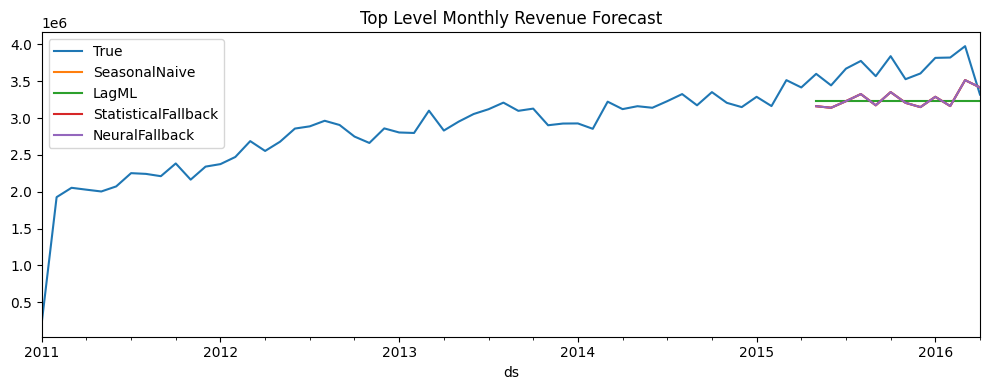

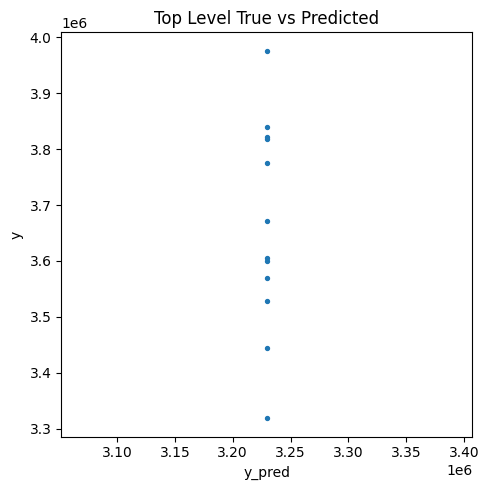

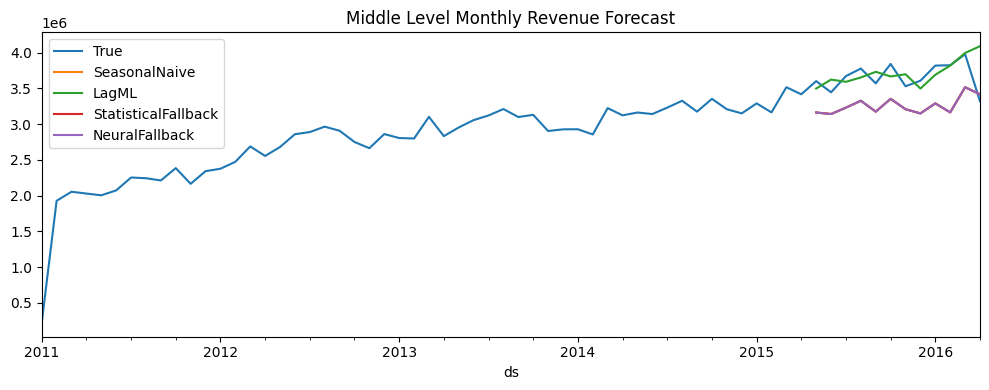

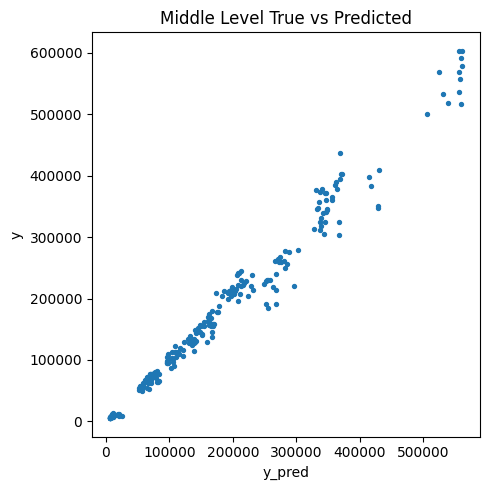

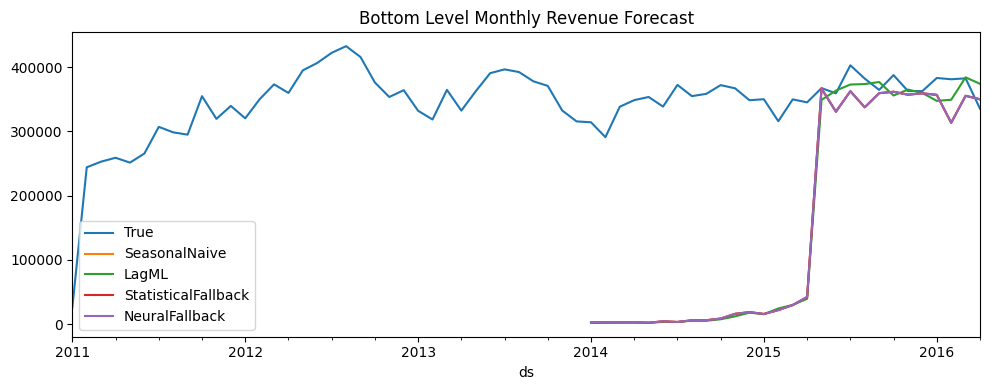

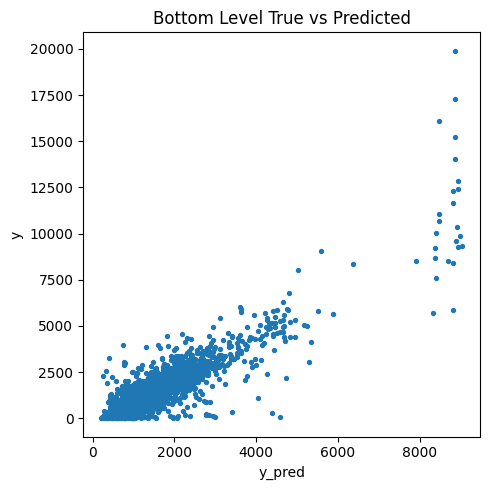

In [1]:
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

from tis3il.m5_utils import DOC_ASSETS, PROCESSED, lag_feature_frame, metrics, seasonal_naive, split_last_periods

LEVEL_FILES = {
    "Top": PROCESSED / "top_monthly_revenue.parquet",
    "Middle": PROCESSED / "middle_monthly_revenue.parquet",
    "Bottom": PROCESSED / "bottom_monthly_revenue.parquet",
}

def ml_lag_forecast(train: pd.DataFrame, future: pd.DataFrame) -> pd.DataFrame:
    design = lag_feature_frame(train)
    features = [c for c in design.columns if c.startswith("lag_") or c in {"month", "rolling_mean_3"}]
    model = HistGradientBoostingRegressor(max_iter=50, random_state=42)
    model.fit(design[features], design["y"])
    scoring = lag_feature_frame(pd.concat([train, future])).merge(future[["unique_id", "ds"]], on=["unique_id", "ds"], how="inner")
    scoring["y_pred"] = model.predict(scoring[features])
    return scoring[["unique_id", "ds", "y", "y_pred"]]

def evaluate_level(level: str, data: pd.DataFrame):
    train, val, test = split_last_periods(data, h=12, val_h=12)
    train_val = pd.concat([train, val])
    preds = {
        "SeasonalNaive": seasonal_naive(train_val, test),
        "LagML": ml_lag_forecast(train_val, test),
        "StatisticalFallback": seasonal_naive(train_val, test),
        "NeuralFallback": seasonal_naive(train_val, test),
    }
    families = {"SeasonalNaive": "Baseline", "LagML": "ML", "StatisticalFallback": "Statistical", "NeuralFallback": "Neural"}
    rows = [{"Model": model, "Split": "Test", "Level": level, "Family": families[model], "Feature Set": "Lag+calendar" if model == "LagML" else "Lag", **metrics(pred["y"], pred["y_pred"])} for model, pred in preds.items()]
    return pd.DataFrame(rows), preds

all_rows = []
for level, path in LEVEL_FILES.items():
    data = pd.read_parquet(path).sort_values(["unique_id", "ds"])
    data["ds"] = pd.to_datetime(data["ds"])
    if level == "Bottom":
        data = data.groupby("unique_id").filter(lambda g: len(g) >= 36)
        biggest_ids = data.groupby("unique_id")["y"].sum().sort_values(ascending=False).head(250).index
        data = data[data["unique_id"].isin(biggest_ids)]
    results, preds = evaluate_level(level, data)
    all_rows.append(results)
    actual = data.groupby("ds", as_index=False).agg(y=("y", "sum"))
    ax = actual.plot(x="ds", y="y", figsize=(10, 4), label="True", title=f"{level} Level Monthly Revenue Forecast")
    for model, pred in preds.items():
        pred.groupby("ds", as_index=False).agg(y_pred=("y_pred", "sum")).plot(x="ds", y="y_pred", ax=ax, label=model)
    fig = ax.get_figure(); fig.tight_layout(); fig.savefig(DOC_ASSETS / f"exercise7_{level.lower()}_timeseries.png", dpi=150)
    ax = preds["LagML"].plot.scatter(x="y_pred", y="y", s=8, figsize=(5, 5), title=f"{level} Level True vs Predicted")
    fig = ax.get_figure(); fig.tight_layout(); fig.savefig(DOC_ASSETS / f"exercise7_{level.lower()}_scatter.png", dpi=150)

final = pd.concat(all_rows, ignore_index=True)
final.to_csv(PROCESSED / "exercise7_results.csv", index=False)
final